In [93]:

import numpy as np

from Kea.statistics.spectra import per_spectra, spectra_base, strfn_spectra
from Kea.statistics.statfunc import statfunc_base, strfn
from Kea.statistics import statistics_base
from Kea.utils import plotting, data_writer

import sympy as sp

import h5py as h5

import time

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.axes as maxes
plotting.modify_rc()

twopi = 2.*np.pi

from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u

from scipy.signal import windows


In [94]:

f0 = fits.open('/home/m/Documents/science_codes/Data/LMC/LMC_SED_Mass.fits')


In [95]:
f0[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 1250                                                  
NAXIS2  =                 1250                                                  
EXTEND  =                    T                                                  
WCSAXES =                    2                                                  
CRVAL1  =              80.8942                                                  
CRVAL2  =             -69.7561                                                  
CRPIX1  =                625.0                                                  
CRPIX2  =                625.0                                                  
CDELT1  =                -0.01                                                  
CDELT2  =                 0.

In [96]:

da = (0.01 * u.deg).to(u.rad)
dist = 50.*u.kpc
dx = (dist * np.tan(da)).value
print(dx*u.kpc)
print(1024*dx*u.kpc)

N = 1024#int(f0[0].header['NAXIS1'])
L = dx*N#float(f0[0].header['CDELT2'])*N
D = 2
phys_dims = (L, L)
grid_dims = (N, N)
dk = twopi/L

original = f0[0].data[625-512:625+512,625-512:625+512]
windowed = original * statistics_base.ndim_func(windows.tukey, (N, N), (N, 0.4))

uncert = f0[1].data[625-512:625+512,625-512:625+512]



0.008726646348581266 kpc
8.936085860947216 kpc


Text(95.20631465651071, -73.21695012299828, '1 kpc')

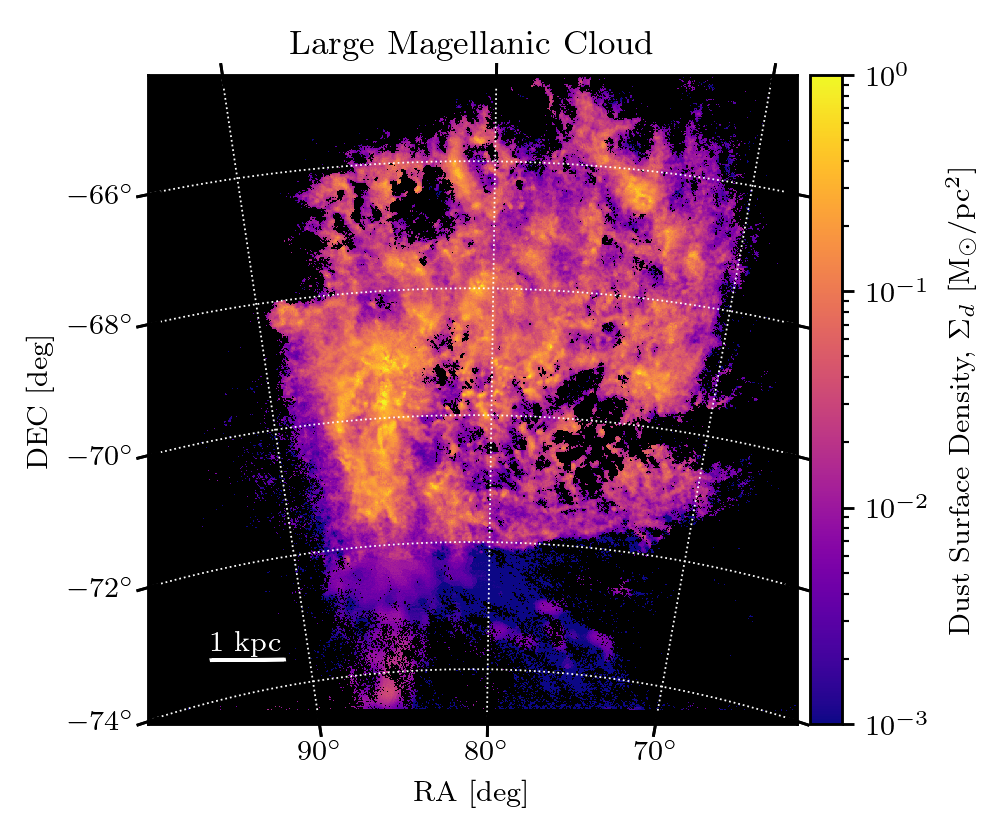

In [98]:

header2 = f0[0].header
header2['CRPIX1'] = 512
header2['CRPIX2'] = 512
header2['NAXIS1'] = 1024
header2['NAXIS2'] = 1024

wcs_helix = WCS(header2)

fig = plt.figure(figsize=(3.5, 3.5), dpi=256)
ax = plt.subplot(projection=wcs_helix)

ax.set_title('Large Magellanic Cloud')

cmap = mpl.colormaps.get('plasma')
cmap.set_bad('black')
im = ax.imshow(f0[0].data[625-512:625+512,625-512:625+512], origin='lower', cmap=cmap, aspect='equal', norm=LogNorm(1e-3, 1e0), interpolation='none')
#fig.colorbar(im, ax=ax)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05, axes_class=maxes.Axes)
cbar = fig.colorbar(im, cax=cax, orientation='vertical')
#cax.set_ylabel(r'[M$_\odot$/pc$^2$]')
cax.set_ylabel(r'Dust Surface Density, $\Sigma_d$ [M$_\odot$/pc$^2$]')

overlay = ax.get_coords_overlay('icrs')
overlay.grid(color='white', ls='dotted', linewidth=0.5)

overlay['ra'].set_auto_axislabel(False)
overlay['dec'].set_auto_axislabel(False)
overlay['ra'].set_ticklabel('none')
overlay['dec'].set_ticklabel('none')

ax.coords[0].set_format_unit('deg')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in', labelleft=True, labelright=False)
ax.tick_params(axis='x', direction='in', labelbottom=True, labeltop=False)

ax.set_ylabel('DEC [deg]')
ax.set_xlabel('RA [deg]')

x1, y1 = wcs_helix.pixel_to_world_values(100., 100.)
x2, y2 = wcs_helix.pixel_to_world_values(100.+(1./dx), 100.+1.)
x3, y3 = wcs_helix.pixel_to_world_values(100., 115.)

ax.arrow(x1, y1, x2-x1, y2-y1, 
         head_width=0, head_length=0, 
         fc='white', ec='white', width=0.003, 
         transform=ax.get_transform('icrs'))
plt.text(x3, y3, '1 kpc', 
         color='white', 
         transform=ax.get_transform('icrs'))

# xmin, ymin = wcs_helix.pixel_to_world_values(625-512, 625-512)
# xmax, ymax = wcs_helix.pixel_to_world_values(625+512, 625+512)
# ax.set_xlim((xmin, xmax))
# ax.set_ylim((ymin, ymax))


Text(100.0, 115.0, '1 kpc')

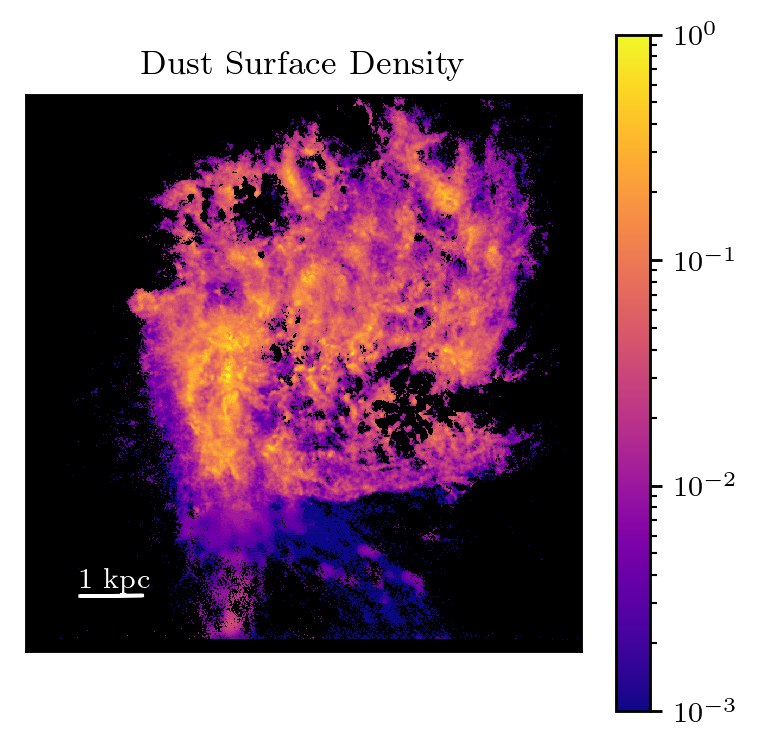

In [58]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)
cmap = mpl.colormaps.get('plasma')
cmap.set_bad('black')

im = ax.imshow(original, cmap=cmap, norm=LogNorm(1e-3, 1e0), origin='lower', interpolation='none')
fig.colorbar(im, ax=ax)

ax.set_xticks([])
ax.set_yticks([])

ax.set_title('Dust Surface Density')

ax.arrow(100., 100, 1./dx, 1., 
         head_width=0, head_length=0, 
         fc='white', ec='white', width=0.003)
plt.text(100., 115., '1 kpc', 
         color='white')



Text(100.0, 115.0, '1 kpc')

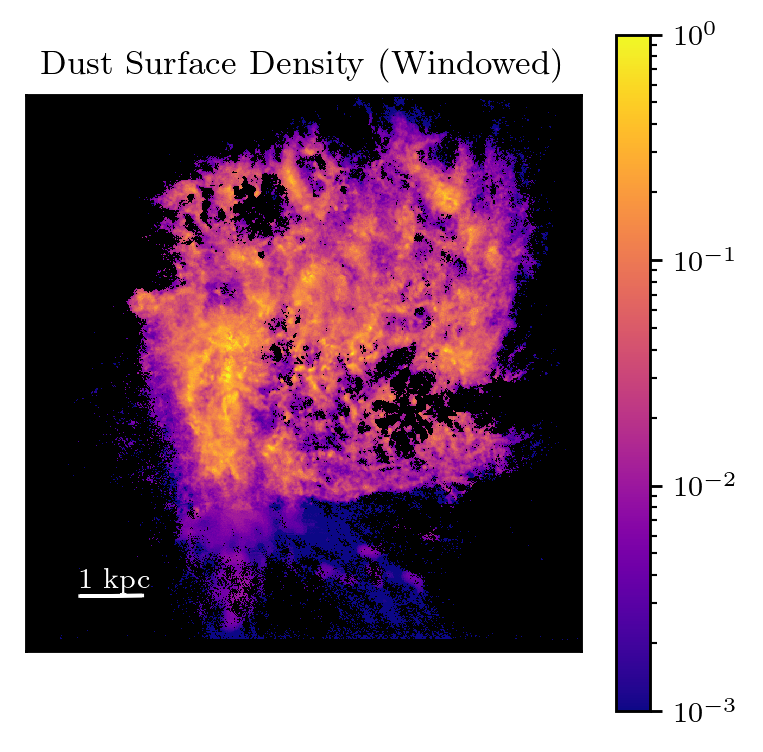

In [78]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)
cmap = mpl.colormaps.get('plasma')
cmap.set_bad('black')

im = ax.imshow(windowed, norm=LogNorm(1e-3, 1e0), cmap=cmap, origin='lower', interpolation='none')
fig.colorbar(im, ax=ax)

ax.set_xticks([])
ax.set_yticks([])

ax.set_title('Dust Surface Density (Windowed)')

ax.arrow(100., 100, 1./dx, 1., 
         head_width=0, head_length=0, 
         fc='white', ec='white', width=0.003)
plt.text(100., 115., '1 kpc', 
         color='white')



Text(100.0, 115.0, '1 kpc')

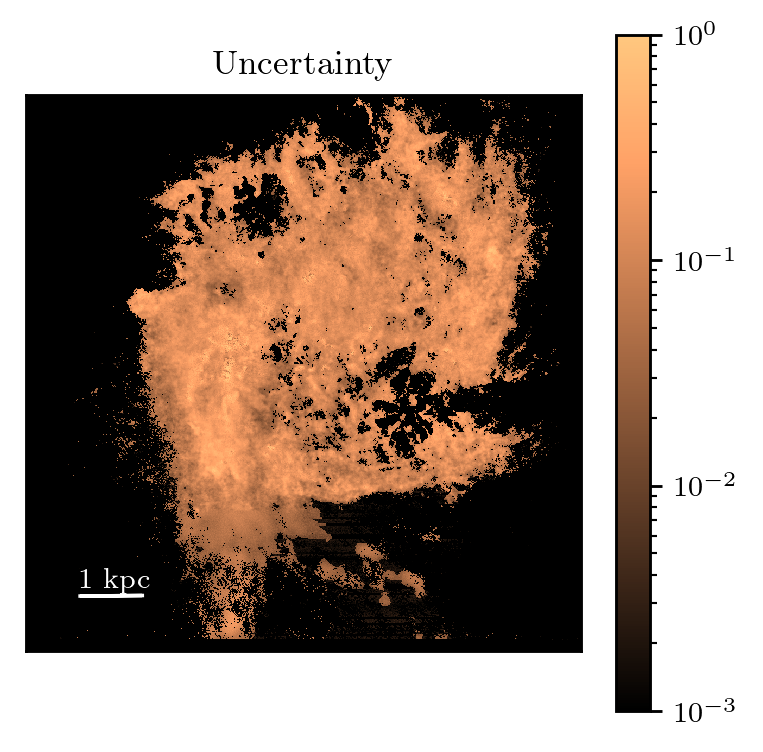

In [79]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)
cmap = mpl.colormaps.get('copper')
cmap.set_bad('black')

im = ax.imshow(uncert, cmap=cmap, norm=LogNorm(1e-3, 1e0), origin='lower', interpolation='none')
fig.colorbar(im, ax=ax)

ax.set_xticks([])
ax.set_yticks([])

ax.set_title('Uncertainty')

ax.arrow(100., 100, 1./dx, 1., 
         head_width=0, head_length=0, 
         fc='white', ec='white', width=0.003)
plt.text(100., 115., '1 kpc', 
         color='white')



Text(0.5, 1.0, 'Taper \\% Test')

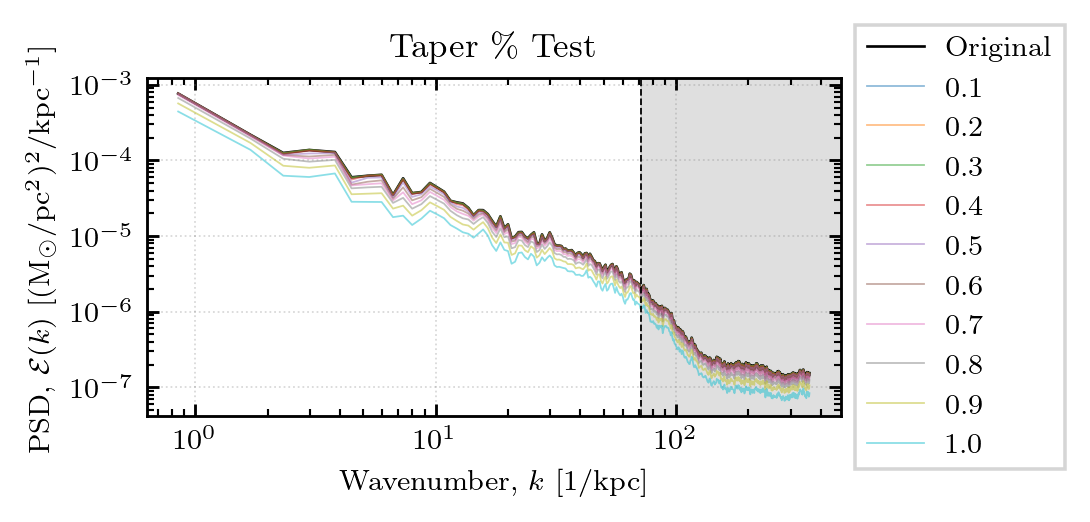

In [82]:

## TEST TAPERS
fig, ax = plt.subplots(1, 1, dpi=256, figsize=(3.5, 1.75))
ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
ax.set_ylabel(r'PSD, $\mathcal{E}(k)$ [(M$_\odot$/pc$^{2}$)$^2$/kpc$^{-1}$]')
ax.set_xlabel(r'Wavenumber, $k$ [1/kpc]')

zerod = original.copy()
zerod[np.isnan(zerod)] = 0.

kD, fekD = per_spectra.modal_spectrum(zerod, phys_dims=phys_dims)
fekD = fekD * (dk/twopi)**D
ko, feko, w = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)
ax.plot(ko, feko, linewidth=0.75, label='Original', color='black')

for p in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.]:
    win = statistics_base.ndim_func(windows.tukey, (N, N), (N, p))
    p_test = zerod * win
    kD, fekD = per_spectra.modal_spectrum(p_test, phys_dims=phys_dims)
    fekD = fekD * (dk/twopi)**D# / np.mean(win**2)
    ko, feko, w = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)
    ax.plot(ko, feko, linewidth=0.5, label=p, alpha=0.5)

FWHM = 0.014
ax.axvline(1./FWHM, color='black', linewidth=0.5, linestyle='--')
rect2 = patches.Rectangle((1./FWHM, ax.get_ylim()[0]), ax.get_xlim()[1], ax.get_ylim()[1], linewidth=0.5, edgecolor='gray', facecolor='gray', linestyle='-', alpha=0.25, zorder=0)
ax.add_patch(rect2)

ax.legend(fancybox=False, loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title(r'Taper \% Test')


Text(100.0, 115.0, '1 kpc')

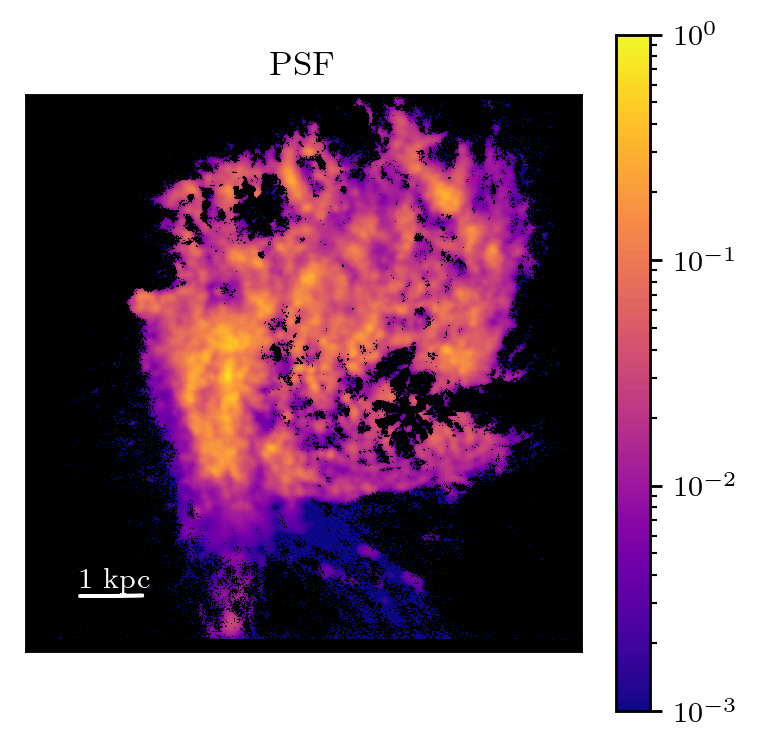

In [179]:

from Kea.statistics import scale_filter

zerod = original.copy()
zerod[np.isnan(zerod)] = 0.
zerod2 = scale_filter.gaussian_scale_greater(zerod, 4)
zerod2[np.isnan(original)] = np.nan

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)
cmap = mpl.colormaps.get('plasma')
cmap.set_bad('black')

im = ax.imshow(zerod2, cmap=cmap, norm=LogNorm(1e-3, 1e0), origin='lower', interpolation='none')
fig.colorbar(im, ax=ax)

ax.set_xticks([])
ax.set_yticks([])

ax.set_title('PSF')

ax.arrow(100., 100, 1./dx, 1., 
         head_width=0, head_length=0, 
         fc='white', ec='white', width=0.003)
plt.text(100., 115., '1 kpc', 
         color='white')


(1e-07, 0.001)

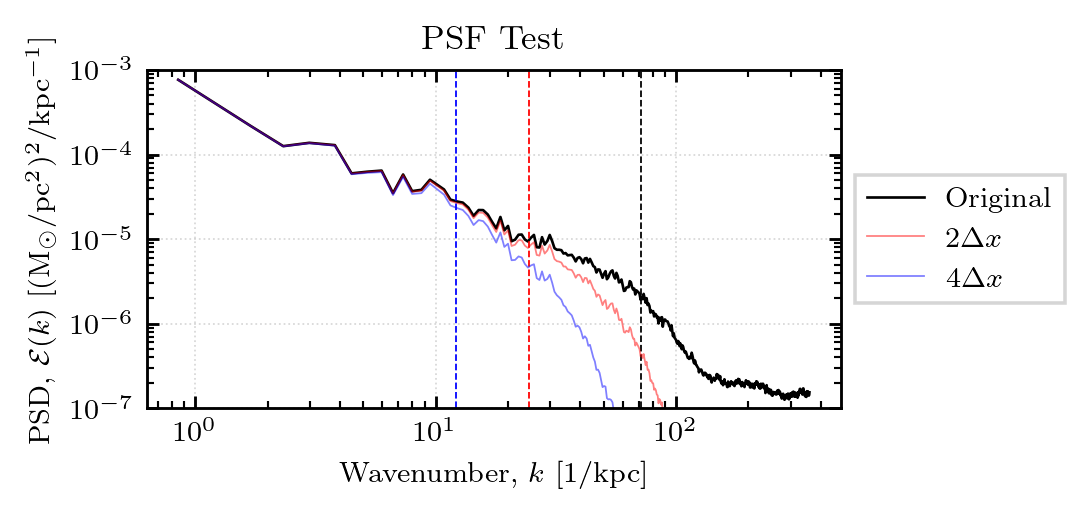

In [92]:

## TEST PSF FWHM
fig, ax = plt.subplots(1, 1, dpi=256, figsize=(3.5, 1.75))
ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
ax.set_ylabel(r'PSD, $\mathcal{E}(k)$ [(M$_\odot$/pc$^{2}$)$^2$/kpc$^{-1}$]')
ax.set_xlabel(r'Wavenumber, $k$ [1/kpc]')

zerod = original.copy()
zerod[np.isnan(zerod)] = 0.

kD, fekD = per_spectra.modal_spectrum(zerod, phys_dims=phys_dims)
fekD = fekD * (dk/twopi)**D
ko, feko, w = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)
ax.plot(ko, feko, linewidth=0.75, label='Original', color='black')
FWHM = 0.014
ax.axvline(1./FWHM, linewidth=0.5, linestyle='--', color='black')

## sigma = 2.*dx
## => FWHM = sigma * sqrt(8*ln(2))

from Kea.statistics import scale_filter
zerod2 = scale_filter.gaussian_scale_greater(zerod, 2)
kD, fekD = per_spectra.modal_spectrum(zerod2, phys_dims=phys_dims)
fekD = fekD * (dk/twopi)**D
ko, feko, w = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)
ax.plot(ko, feko, linewidth=0.5, alpha=0.5, color='red', label=r'$2 \Delta x$')
ax.axvline(1./(2.*dx*np.sqrt(8.*np.log(2.))), linewidth=0.5, linestyle='--', color='red')

zerod3 = scale_filter.gaussian_scale_greater(zerod, 4)
kD, fekD = per_spectra.modal_spectrum(zerod3, phys_dims=phys_dims)
fekD = fekD * (dk/twopi)**D
ko, feko, w = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)
ax.plot(ko, feko, linewidth=0.5, alpha=0.5, color='blue', label=r'$4 \Delta x$')
ax.axvline(1./(4.*dx*np.sqrt(8.*np.log(2.))), linewidth=0.5, linestyle='--', color='blue')

ax.legend(fancybox=False, loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title(r'PSF Test')

ax.set_ylim((1e-7, 1e-3))


In [101]:

zerod = windowed.copy()
zerod[np.isnan(zerod)] = 0.

kD, fekD = per_spectra.modal_spectrum(zerod, phys_dims=phys_dims)
fekD = fekD * (dk/twopi)**D
ko, feko, w = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)

kb, fekb, _ = statistics_base.bin_data(
    ko, feko, bin_func=np.nanmean,
    bin_loc='true_center', log_space=True, min_bin=np.nanmin(ko), max_bin=np.nanmax(ko),
    num_bins=24)


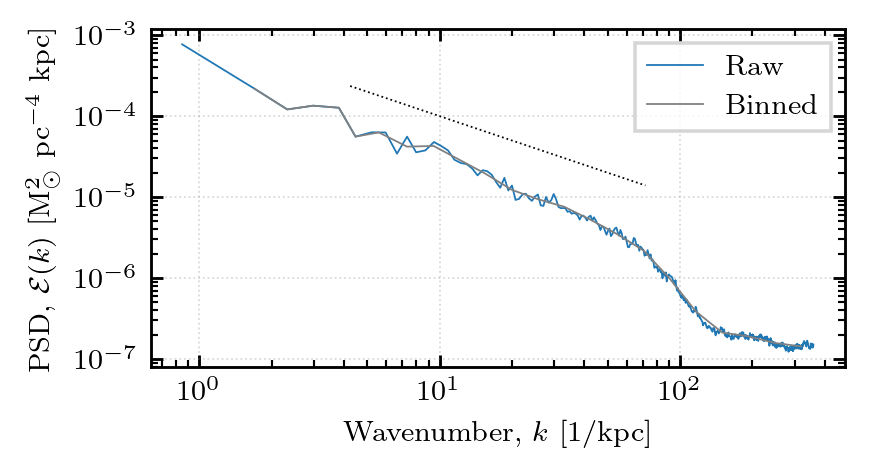

In [94]:

def plot_spec(raw, binned, title=None):
    fig, ax = plt.subplots(1, 1, dpi=256, figsize=(3.5, 1.75))
    ax.plot(raw[0], raw[1], linestyle='-', linewidth=0.5, label='Raw')
    ax.plot(binned[0], binned[1], linestyle='-', color='gray', linewidth=0.5, label='Binned')
    #ax.fill_between(raw[0], raw[1]-1*raw[2], raw[1]+1*raw[2], edgecolor='none', alpha=0.5, facecolor='red')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
    ax.set_ylabel(r'PSD, $\mathcal{E}(k)$ [M$_\odot^2$ pc$^{-4}$ kpc]')
    ax.set_xlabel(r'Wavenumber, $k$ [1/kpc]')
    ax.legend(fancybox=False)
    ax.set_title(title)
    _k = np.exp(np.linspace(np.log(np.min(raw[0])*5), np.log(np.max(raw[0])/5), 100))
    #ax.plot(_k, 5e1*_k**(-2.), linestyle=':', color='black', linewidth=0.5)
    ax.plot(_k, 1e-3*_k**(-1.), linestyle=':', color='black', linewidth=0.5)

plot_spec((ko, feko), (kb, fekb))


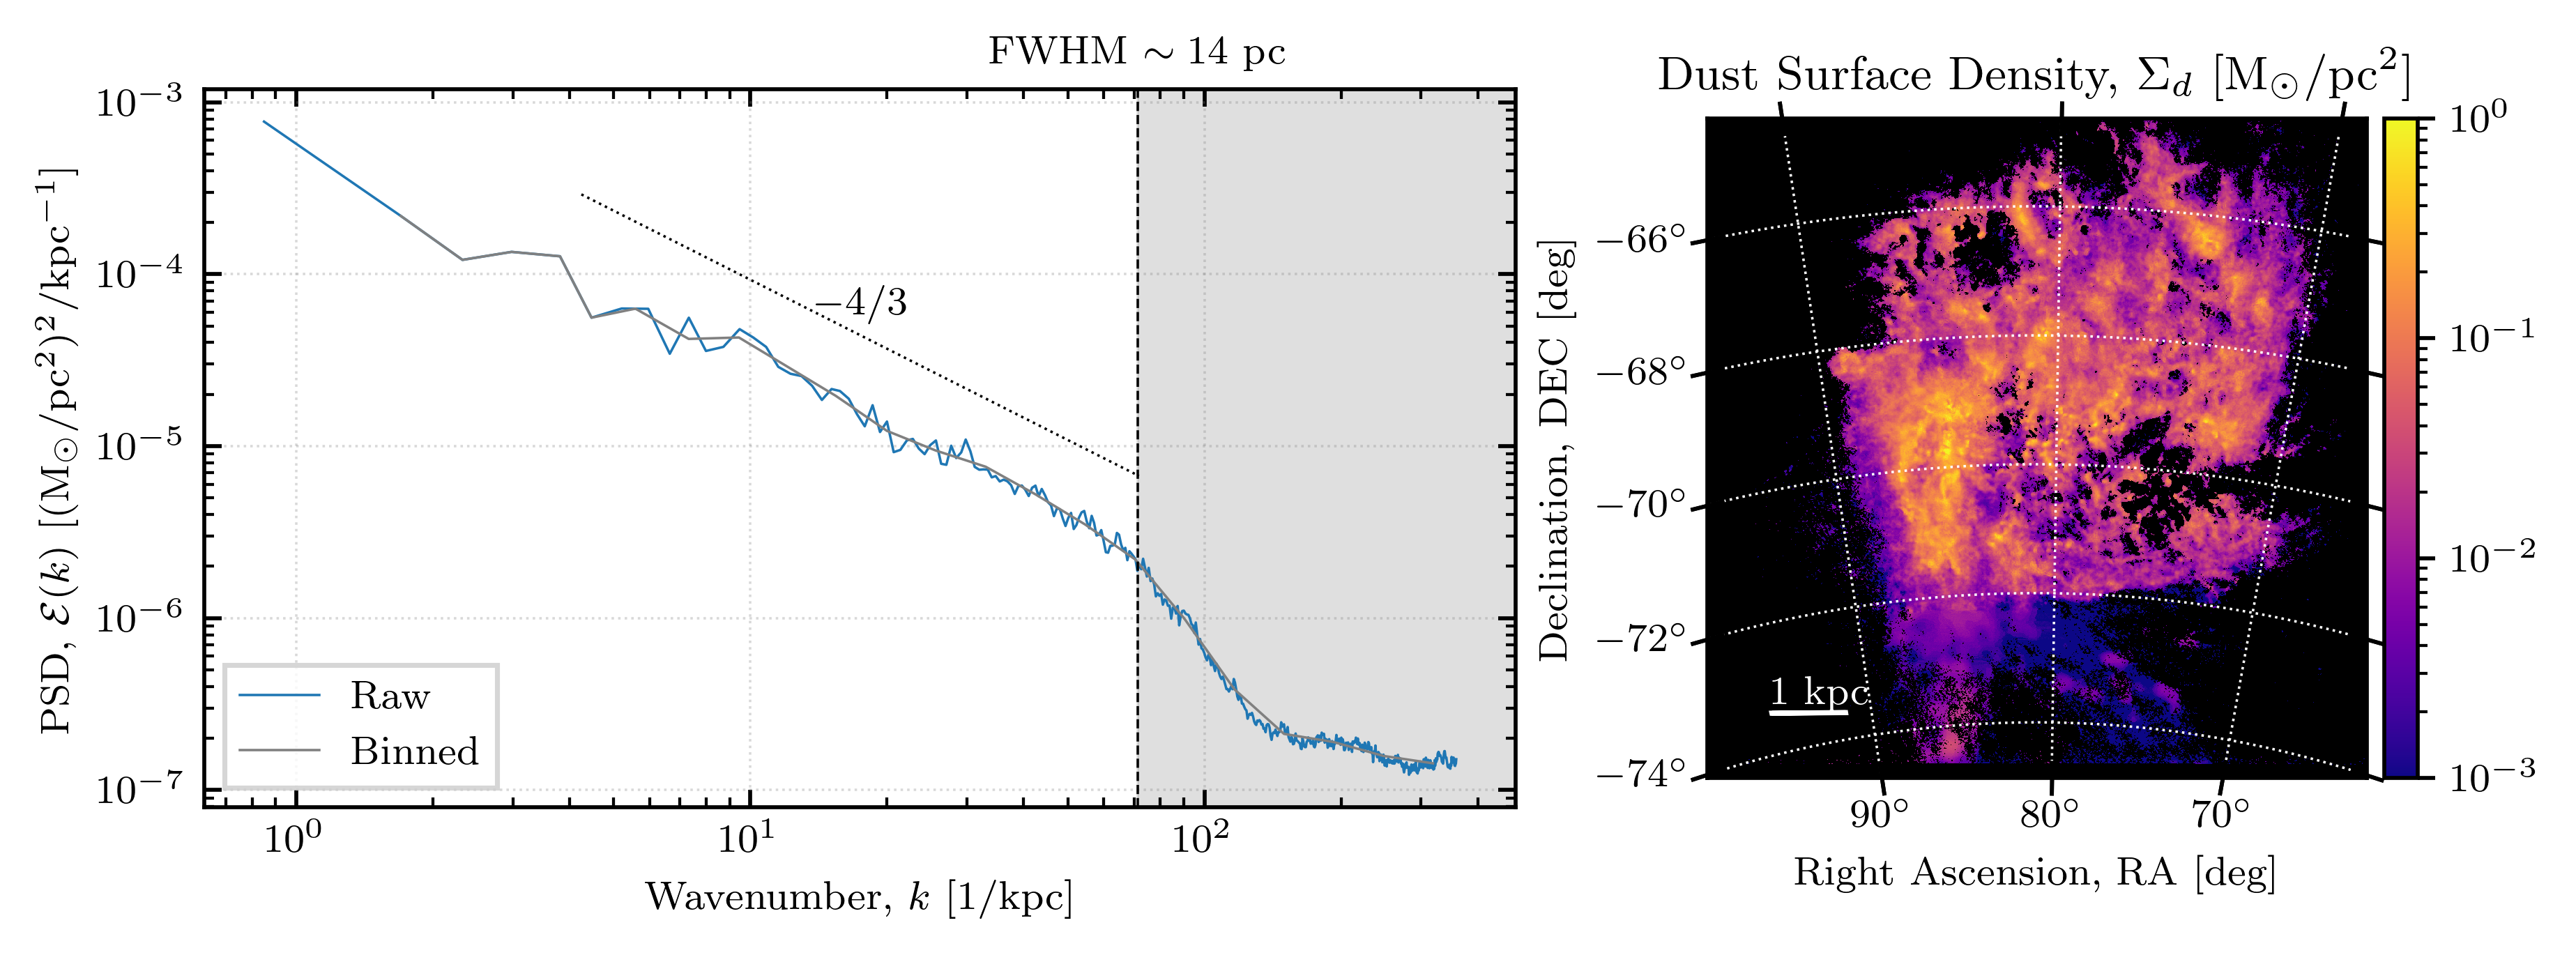

In [168]:

def calc_sf(sf, grid_dims, phys_dims, num_bins=32, log_space=True):
    N = grid_dims[0]
    L = phys_dims[0]
    dx = L/N
    lvm_f = statfunc_base.get_lagvec_magnitude_array([n for n in grid_dims]) * dx

    l_f2, sf2_f2, w_f2 = statistics_base.bin_data(
        lvm_f, sf, bin_func=np.nanmean,
        cut_excess=True, nan_small=False,
        min_bin=dx, max_bin=L/2., num_bins=N//2,
        bin_loc='center', log_space=True)

    l_f2_t = l_f2[np.isfinite(sf2_f2)]
    sf2_f2_t = sf2_f2[np.isfinite(sf2_f2)]
    sf2_f2 = strfn_spectra.interpolate(l_f2_t, sf2_f2_t, l_f2)

    l_b, sf2_b, _ = statistics_base.bin_data(
        l_f2, sf2_f2, bin_func=np.nanmean,
        bin_loc='true_center', log_space=log_space, min_bin=dx, max_bin=L/2.,
        num_bins=num_bins)

    return (l_f2, sf2_f2), (l_b, sf2_b)

def plot_sf(raw, binned, title=None):
    fig, ax = plt.subplots(1, 1, dpi=256, figsize=(3.5, 1.75))
    ax.plot(raw[0], raw[1], linestyle='-', color='red', linewidth=0.75, label='Raw')
    ax.plot(binned[0], binned[1], linestyle='--', color='blue', linewidth=0.75, label='Binned', marker='X', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
    ax.set_xlabel(r'Length-scale, $\ell$ [kpc]')
    ax.set_ylabel(r'SF, $S_2(\ell)$ [(M$_\odot$ pc$^{-2}$)$^2$]')
    ax.legend(fancybox=False)
    ax.set_title(title)

    FWHM = 0.014
    ax.axvline(FWHM, linestyle='--', color='black', linewidth=0.5)
    #SIG = FWHM / np.sqrt(8.*np.log(2.))
    #ax.axvline(SIG, linestyle=':', color='black', linewidth=0.5)


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


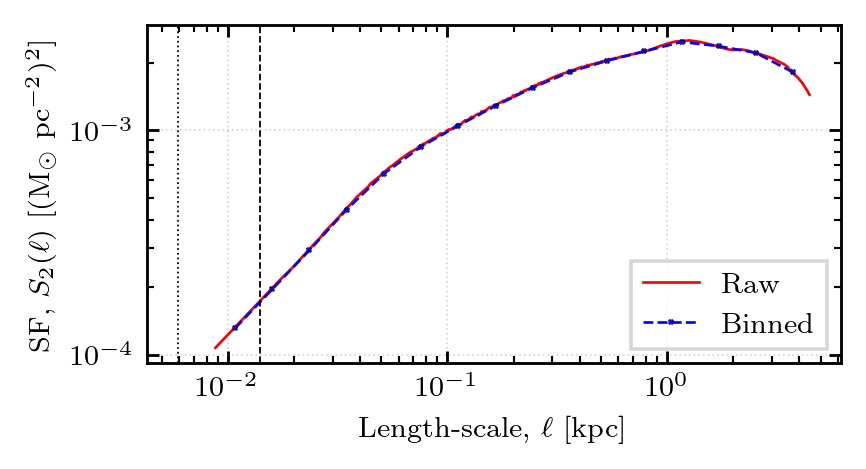

In [169]:

sf = np.load('sf2d_win_nan_dx.npy')
sf, sfb = calc_sf(sf, grid_dims, phys_dims, num_bins=16)

plot_sf(sf, sfb)


In [166]:

def plot_all_spectra(raw, binned, fekb1, fekb2, fekb3, title=None):

    fig, ax = plt.subplots(1, 1, dpi=256, figsize=(3.5, 1.75))

    ax.plot(raw[0], raw[1], linewidth=0.5, alpha=0.35, zorder=0, label='Raw')
    ax.plot(binned[0], binned[1], linewidth=0.75, zorder=0, label='Binned', color='gray')

    ax.plot(fekb1[0], fekb1[1]/fekb1[2], color='red', linestyle='--', linewidth=0.5, label=r'$b=1$', marker='X', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)
    ax.plot(fekb2[0], fekb2[1]/fekb2[2], color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$')
    ax.plot(fekb3[0], fekb3[1]/fekb3[2], color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$')

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    ax.legend(frameon=True, fancybox=False, loc='lower left')
    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.yaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.yaxis.set_minor_locator(locmin)

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.xaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.xaxis.set_minor_locator(locmin)

    ax.set_ylabel(r'PSD, $\mathcal{E}(k)$ [M$_\odot^2$ pc$^{-4}$ kpc]')
    ax.set_xlabel(r'Wavenumber, $k$ [1/kpc]')

    fig.align_ylabels()


def omni_spectrum(ko, ell, sf2, phys_dims, grid_dims, a, b):

    _dx = phys_dims[0]/grid_dims[0]
    _dk = 2.*np.pi/phys_dims[0]

    dS = np.gradient(sf2, _dx)
    dell = np.gradient(ell, _dx)

    fek = (ell)**2 * (dS/dell) * (1. / 2.) / a
    kk = b / ell

    kk = kk[::-1]
    fek = fek[::-1]

    return kk, fek

    # kmin = np.nanmin(ko)
    # kmax = np.nanmax(kk)
    # fek = fek[kk > kmin]
    # kk = kk[kk > kmin]

    # _kk = ko[ko < kmax]
    # _fek = fek
    # _fek = strfn_spectra.interpolate(kk, _fek, _kk)

    # return _kk, _fek


from scipy.interpolate import interp1d
def interpolate(x, y, x_interp):
    f_int = interp1d(np.log10(x), y, kind='linear', fill_value='extrapolate')
    fek_new = f_int(np.log10(x_interp))
    return fek_new


def get_powerlaw(k, fek, num_bins=16, log_space=False):
    est_alpha = np.gradient(np.log(fek), np.log(k))
    if num_bins is None:
        return est_alpha
    b_k, b_est_alpha, _ = statistics_base.bin_data(
        k, est_alpha, bin_func=np.nanmean, log_space=log_space,
        bin_loc='left', num_bins=num_bins, min_bin=np.nanmin(k), max_bin=np.nanmax(k),
        ignore_nan=True)
    est_alpha = interpolate(b_k, b_est_alpha, k)
    return est_alpha

def debias(est_alpha, b, D):
    sp_beta = sp.symbols('beta', positive=True, real=True)
    sp_D = sp.symbols('D', positive=True, real=True)
    sp_b = sp.symbols('b', positive=True, real=True)
    spec_bias = sp.S(2)*sp.S(2)**(-sp_beta) * sp_b**(sp_beta - sp.S(1)) * (sp.gamma(sp_D/sp.S(2)) * sp.gamma((sp.S(3) - sp_beta) / sp.S(2))/sp.gamma(sp_D/sp.S(2) + sp_beta/sp.S(2) - sp.Rational(1,2)))
    spec_bias = spec_bias.subs({sp_D: sp.S(D), sp_b: sp.S(b)})

    #bias_factor = np.zeros_like(est_alpha)
    est_alpha[est_alpha > -1.01] = -1.01
    est_alpha[est_alpha < -2.99] = -2.99

    f_bias = sp.lambdify(sp_beta, spec_bias)
    bias_factor = np.float64(f_bias(-est_alpha))

    #for i, _a in enumerate(est_alpha):
    #    bias_factor[i] = np.float64(f_bias())

    return bias_factor



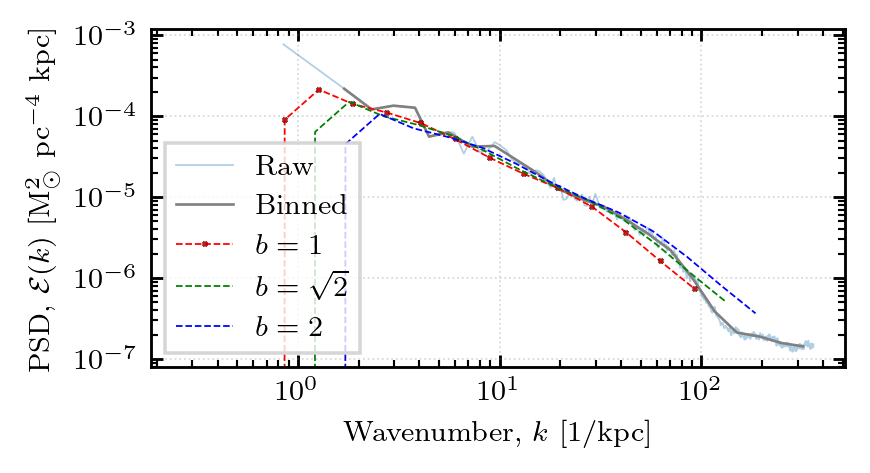

In [167]:

## Get equiv-spectrum
kb1, fekb1 = omni_spectrum(ko, sfb[0], sfb[1], phys_dims, grid_dims, 1., 1.)
kb2, fekb2 = omni_spectrum(ko, sfb[0], sfb[1], phys_dims, grid_dims, np.sqrt(2.), np.sqrt(2.))
kb3, fekb3 = omni_spectrum(ko, sfb[0], sfb[1], phys_dims, grid_dims, 2., 2.)

plot_all_spectra((ko, feko), (kb, fekb), (kb1, fekb1, np.ones_like(fekb1)), (kb2, fekb2, np.ones_like(fekb2)), (kb3, fekb3, np.ones_like(fekb3)), title=None)


In [163]:

def plot_powerlaw(feko, fekb1, fekbb, fekb3, title=None):
    fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

    ax.axhline(-1, color='black', linestyle='-', linewidth=0.25)
    ax.axhline(-3, color='black', linestyle='-', linewidth=0.25)

    ax.plot(feko[0], feko[1], color='gray', linestyle='-', linewidth=0.5, label='Pgram')
    ax.plot(fekb1[0], fekb1[1], color='red', linestyle='--', linewidth=0.5, label=r'$b=1$', marker='X', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)
    ax.plot(fekbb[0], fekbb[1], color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$', marker='o', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)
    ax.plot(fekb3[0], fekb3[1], color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$', marker='v', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)

    FWHM = 0.014
    ax.axvline(1./FWHM, linestyle=':', linewidth=0.5, color='black')

    ax.set_xscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
    ax.set_xlabel(r'Wavenumber, $k$ [1/kpc]')
    ax.set_ylabel(r'd$\ln({\mathcal{E}}(k))/$d$\ln(k)$')
    ax.set_ylim((-5, 1))
    ax.legend(fancybox=False, ncols=2)
    ax.set_title(title)


/tmp/ipykernel_40441/396896594.py:75: RuntimeWarning: invalid value encountered in log
  est_alpha = np.gradient(np.log(fek), np.log(k))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/tmp/ipykernel_40441/396896594.py:75: RuntimeWarning: invalid value encountered in log
  est_alpha = np.gradient(np.log(fek), np.log(k))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/tmp/ipykernel_40441/396896594.py:75: RuntimeWarning: invalid value encountered in log
  est_alpha = np.gradient(np.log(fek), np.log(k))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


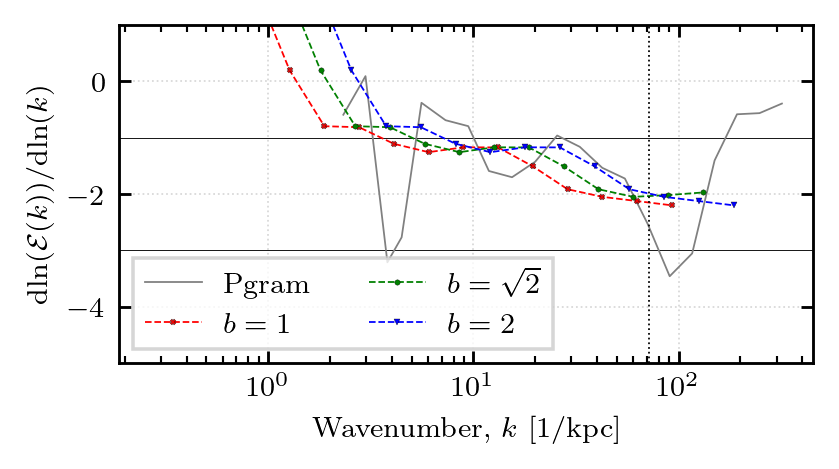

In [164]:

## Estimate powerlaw
a_feko = get_powerlaw(kb, fekb, log_space=False, num_bins=None)
a_fekb1 = get_powerlaw(kb1, fekb1, log_space=True, num_bins=16)
a_fekb2 = get_powerlaw(kb2, fekb2, log_space=True, num_bins=16)
a_fekb3 = get_powerlaw(kb3, fekb3, log_space=True, num_bins=16)

## Plot powerlaw
plot_powerlaw((kb, a_feko), (kb1, a_fekb1), (kb2, a_fekb2), (kb3, a_fekb3), title=None)

## Get debiasing factors
b_b1 = debias(a_fekb1, 1., len(grid_dims))
b_b2 = debias(a_fekb2, np.sqrt(2.), len(grid_dims))
b_b3 = debias(a_fekb3, 2., len(grid_dims))


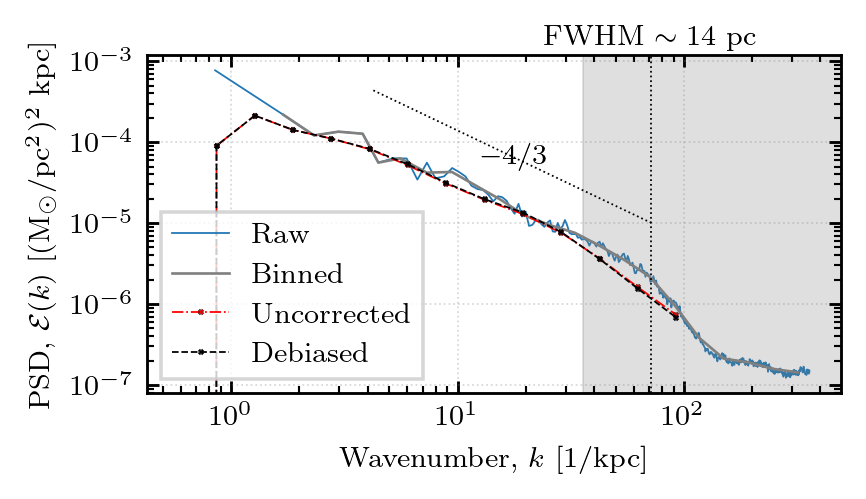

In [165]:


def plot_all_spectra(raw, binned, fekb1, fekb2, fekb3, title=None):

    fig, ax = plt.subplots(1, 1, dpi=256, figsize=(3.5, 1.75))

    ax.plot(raw[0], raw[1], linewidth=0.5, zorder=0, label='Raw')
    ax.plot(binned[0], binned[1], linewidth=0.75, zorder=0, label='Binned', color='gray')

    ax.plot(fekb1[0], fekb1[1], color='red', linestyle='-.', linewidth=0.5, label=r'Uncorrected', marker='X', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)
    ax.plot(fekb1[0], fekb1[1]/fekb1[2], color='black', linestyle='--', linewidth=0.5, label=r'Debiased', marker='X', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)
    #ax.plot(fekb2[0], fekb2[1]/fekb2[2], color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$')
    #ax.plot(fekb3[0], fekb3[1]/fekb3[2], color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$')

    kp1 = np.exp(np.linspace(np.log(np.min(raw[0])*5.), np.log(np.max(raw[0])/5.), 50))
    ax.plot(kp1, 3e-3*kp1**(-4./3.), color='black', linestyle=':', linewidth=0.5)
    props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
    ax.text(kp1[len(kp1)//2], 0.7, r'$-4/3$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')
    #kp53 = np.exp(np.linspace(np.log(5e-3), np.log(1e0), 50))
    #ax.plot(kp53, 1e-1*kp53**(-5./3.), color='black', linestyle=':', linewidth=0.5)

    #kpb = np.exp(np.linspace(np.log(np.min(raw[0])), np.log(np.max(raw[0])), 100))
    FWHM = 0.014
    sig_beam = FWHM / np.sqrt(8.*np.log(2))
    #E_PSF = np.exp(-4.*np.pi**2 * sig_beam**2 * kpb**2)
    #ax.plot(kpb, E_PSF, linewidth=0.5, linestyle='--')
    ax.axvline(1./FWHM, linestyle=':', linewidth=0.5, color='black')
    ax.text(1./FWHM, 1.05, r'FWHM $\sim 14$ pc', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    ax.legend(frameon=True, fancybox=False, loc='lower left')

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.yaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.yaxis.set_minor_locator(locmin)

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.xaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.xaxis.set_minor_locator(locmin)

    ax.set_ylabel(r'PSD, $\mathcal{E}(k)$ [(M$_\odot$/pc$^{2}$)$^2$ kpc]')
    ax.set_xlabel(r'Wavenumber, $k$ [1/kpc]')

    fig.align_ylabels()

    import matplotlib.patches as patches
    rect2 = patches.Rectangle((1./(2.*FWHM), ax.get_ylim()[0]), ax.get_xlim()[1], ax.get_ylim()[1], linewidth=0.5, edgecolor='gray', facecolor='gray', linestyle='-', alpha=0.25, zorder=0)
    ax.add_patch(rect2)

    fig.savefig('LMC_a.pdf', transparent=True, bbox_inches='tight', pad_inches=0)

plot_all_spectra((ko, feko), (kb, fekb), (kb1[2:], fekb1[2:], b_b1[2:]), (kb2[2:], fekb2[2:], b_b2[2:]), (kb3[2:], fekb3[2:], b_b3[2:]), title=None)


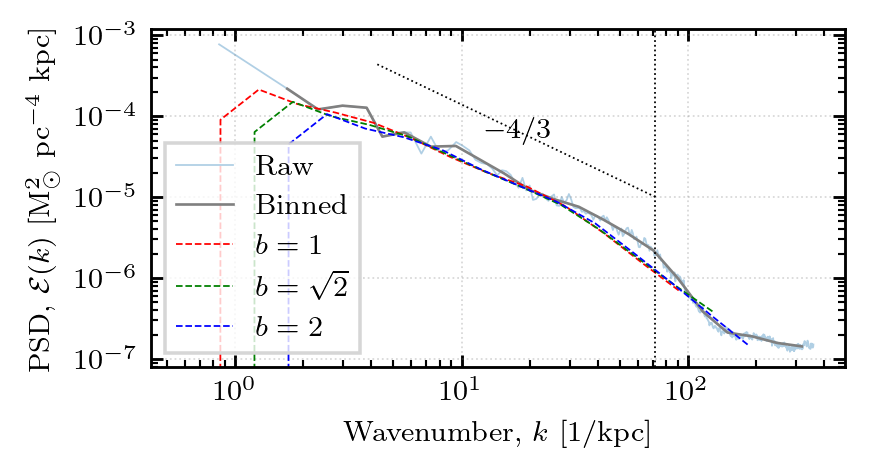

In [159]:


def plot_all_spectra_2(raw, binned, fekb1, fekb2, fekb3, title=None):

    fig, ax = plt.subplots(1, 1, dpi=256, figsize=(3.5, 1.75))

    ax.plot(raw[0], raw[1], linewidth=0.5, alpha=0.35, zorder=0, label='Raw')
    ax.plot(binned[0], binned[1], linewidth=0.75, zorder=0, label='Binned', color='gray')

    ax.plot(fekb1[0], fekb1[1]/fekb1[2], color='red', linestyle='--', linewidth=0.5, label=r'$b=1$')
    ax.plot(fekb2[0], fekb2[1]/fekb2[2], color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$')
    ax.plot(fekb3[0], fekb3[1]/fekb3[2], color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$')

    kp1 = np.exp(np.linspace(np.log(np.min(raw[0])*5.), np.log(np.max(raw[0])/5.), 50))
    ax.plot(kp1, 3e-3*kp1**(-4./3.), color='black', linestyle=':', linewidth=0.5)
    props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
    ax.text(kp1[len(kp1)//2], 0.7, r'$-4/3$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')
    #kp53 = np.exp(np.linspace(np.log(5e-3), np.log(1e0), 50))
    #ax.plot(kp53, 1e-1*kp53**(-5./3.), color='black', linestyle=':', linewidth=0.5)

    #kpb = np.exp(np.linspace(np.log(np.min(raw[0])), np.log(np.max(raw[0])), 100))
    FWHM = 0.014
    sig_beam = FWHM / np.sqrt(8.*np.log(2))
    #E_PSF = np.exp(-4.*np.pi**2 * sig_beam**2 * kpb**2)
    #ax.plot(kpb, E_PSF, linewidth=0.5, linestyle='--')
    ax.axvline(1./FWHM, linestyle=':', linewidth=0.5, color='black')

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    ax.legend(frameon=True, fancybox=False, loc='lower left')

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.yaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.yaxis.set_minor_locator(locmin)

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.xaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.xaxis.set_minor_locator(locmin)

    ax.set_ylabel(r'PSD, $\mathcal{E}(k)$ [M$_\odot^2$ pc$^{-4}$ kpc]')
    ax.set_xlabel(r'Wavenumber, $k$ [1/kpc]')

    fig.align_ylabels()

    fig.savefig('LMC_b.pdf', transparent=True, bbox_inches='tight', pad_inches=0)

plot_all_spectra_2((ko, feko), (kb, fekb), (kb1[2:], fekb1[2:], b_b1[2:]), (kb2[2:], fekb2[2:], b_b2[2:]), (kb3[2:], fekb3[2:], b_b3[2:]), title=None)


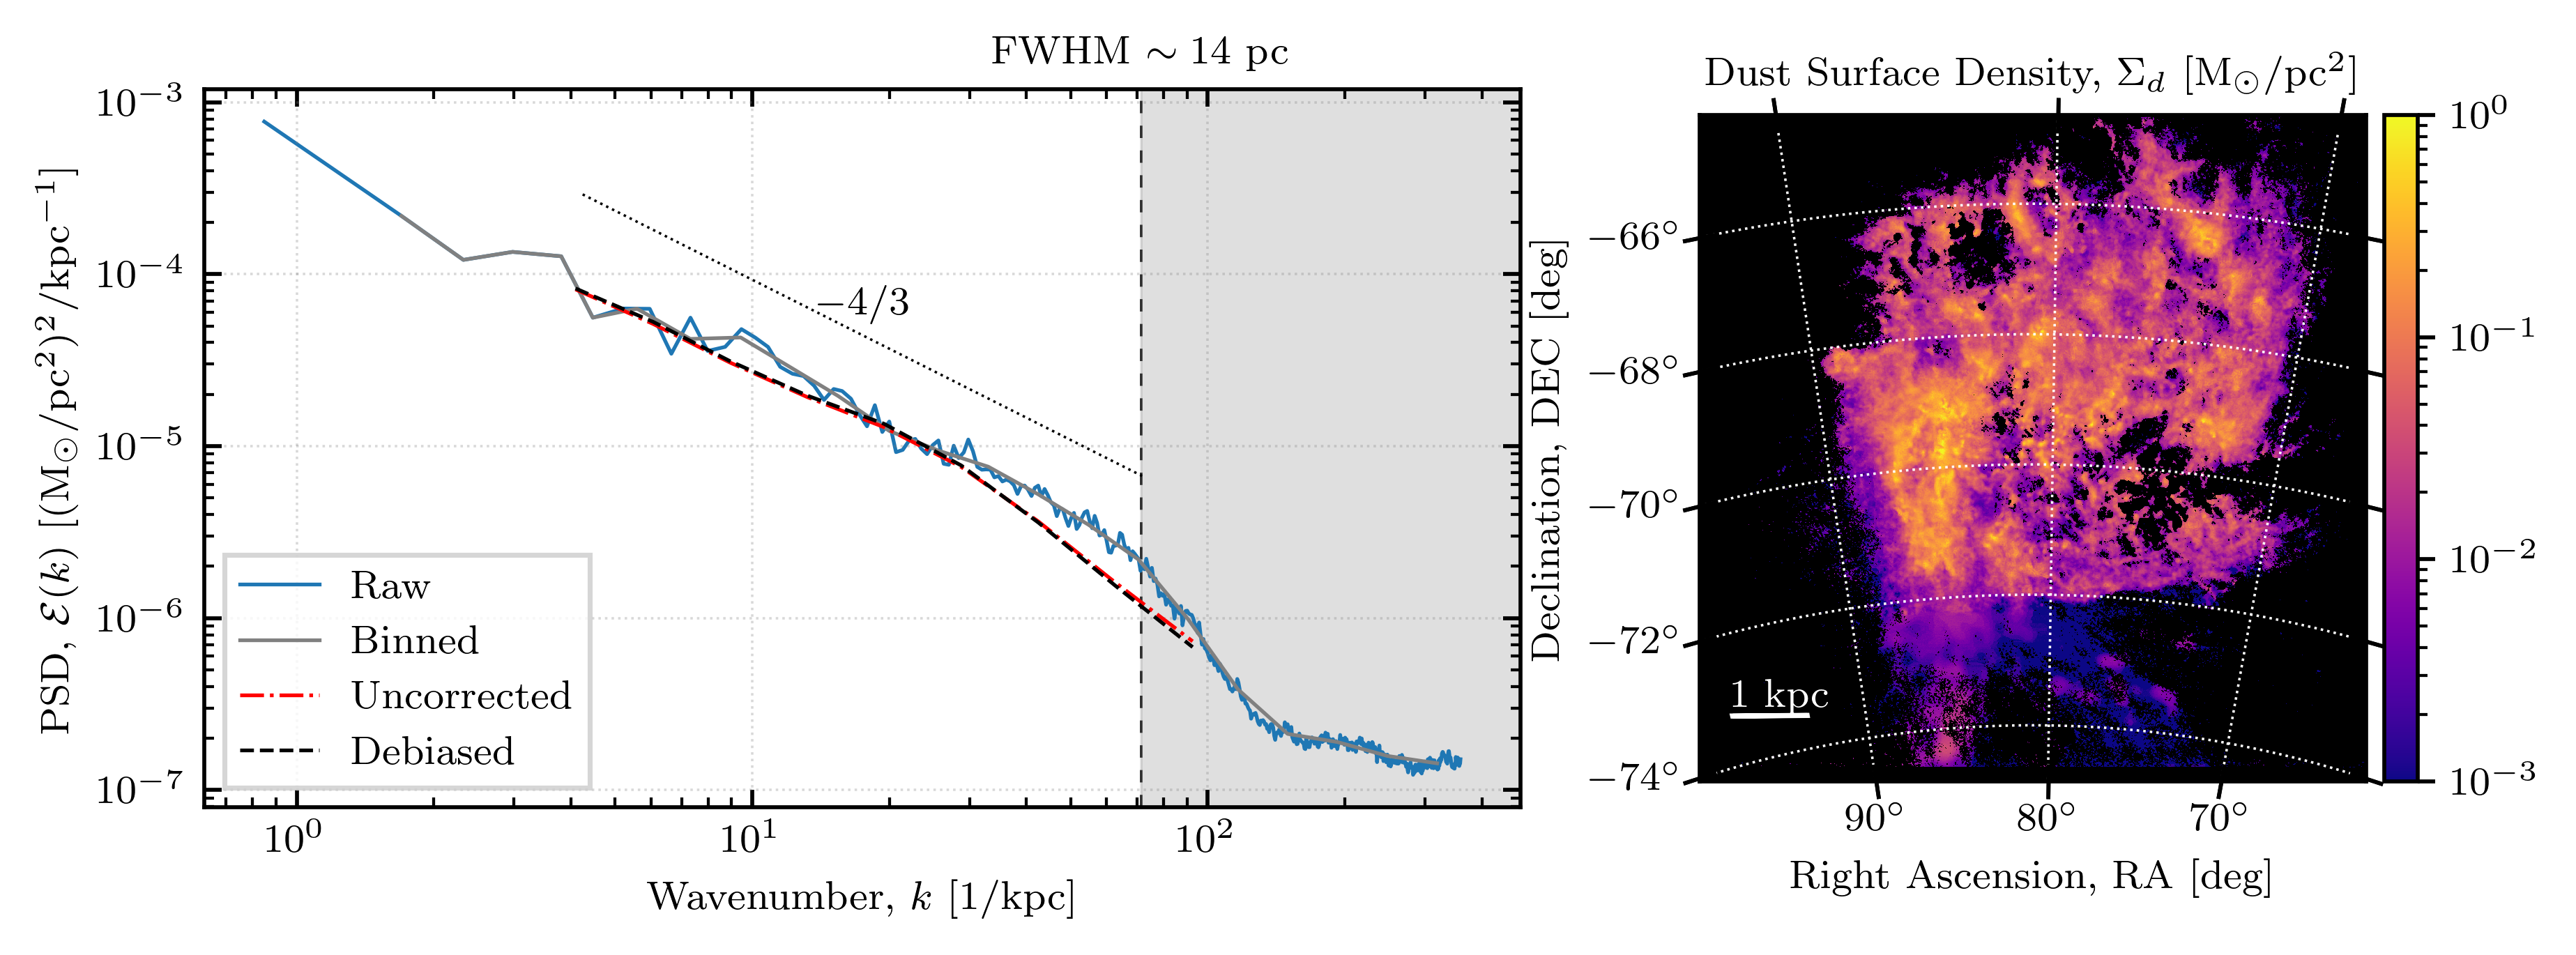

In [160]:

grid = '''
AAAAABBB
AAAAABBB
'''
fig, axs = plt.subplot_mosaic(grid, dpi=512, figsize=(8., 8./3.), per_subplot_kw={'B': {'projection': wcs_helix}})
ax = axs['B']
#fig = plt.figure(figsize=(7., 3.5), dpi=256)
#ax = plt.subplot(projection=wcs_helix)

header2 = f0[0].header
header2['CRPIX1'] = 512
header2['CRPIX2'] = 512
header2['NAXIS1'] = 1024
header2['NAXIS2'] = 1024

wcs_helix = WCS(header2)

#ax.set_title('Large Magellanic Cloud')
ax.set_title(r'Dust Surface Density, $\Sigma_d$ [M$_\odot$/pc$^2$]', fontsize=8.)

cmap = mpl.colormaps.get('plasma')
cmap.set_bad('black')
im = ax.imshow(f0[0].data[625-512:625+512,625-512:625+512], origin='lower', cmap=cmap, aspect='equal', norm=LogNorm(1e-3, 1e0), interpolation='none')
#fig.colorbar(im, ax=ax)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05, axes_class=maxes.Axes)
cbar = fig.colorbar(im, cax=cax, orientation='vertical')
#cax.set_ylabel(r'[M$_\odot$/pc$^2$]')
#cax.set_ylabel(r'Dust Surface Density, $\Sigma_d$ [M$_\odot$/pc$^2$]')

overlay = ax.get_coords_overlay('icrs')
overlay.grid(color='white', ls='dotted', linewidth=0.5)

overlay['ra'].set_auto_axislabel(False)
overlay['dec'].set_auto_axislabel(False)
overlay['ra'].set_ticklabel('none')
overlay['dec'].set_ticklabel('none')

ax.coords[0].set_format_unit('deg')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in', labelleft=True, labelright=False, fontsize=8.)
ax.tick_params(axis='x', direction='in', labelbottom=True, labeltop=False, fontsize=8.)

ax.set_ylabel('Declination, DEC [deg]', fontsize=8.)
ax.set_xlabel('Right Ascension, RA [deg]', fontsize=8.)

x1, y1 = wcs_helix.pixel_to_world_values(50., 100.)
x2, y2 = wcs_helix.pixel_to_world_values(50.+(1./dx), 100.+1.)
x3, y3 = wcs_helix.pixel_to_world_values(50., 115.)

ax.arrow(x1, y1, x2-x1, y2-y1, 
         head_width=0, head_length=0, 
         fc='white', ec='white', width=0.003, 
         transform=ax.get_transform('icrs'))
plt.text(x3, y3, '1 kpc', 
         color='white', 
         transform=ax.get_transform('icrs'))

# xmin, ymin = wcs_helix.pixel_to_world_values(625-512, 625-512)
# xmax, ymax = wcs_helix.pixel_to_world_values(625+512, 625+512)
# ax.set_xlim((xmin, xmax))
# ax.set_ylim((ymin, ymax))

ax = axs['A']
ax.plot(ko, feko, linestyle='-', linewidth=0.75, label='Raw', zorder=1)
ax.plot(kb, fekb, linestyle='-', color='gray', linewidth=0.75, label='Binned', zorder=2)

ax.plot(kb1[7:], fekb1[7:], color='red', linestyle='-.', linewidth=0.75, label=r'Uncorrected', zorder=3)
ax.plot(kb1[7:], fekb1[7:]/b_b1[7:], color='black', linestyle='--', linewidth=0.75, label=r'Debiased', zorder=4)

#ax.fill_between(raw[0], raw[1]-1*raw[2], raw[1]+1*raw[2], edgecolor='none', alpha=0.5, facecolor='red')
ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
ax.set_ylabel(r'PSD, $\mathcal{E}(k)$ [(M$_\odot$/pc$^{2}$)$^2$/kpc$^{-1}$]')
ax.set_xlabel(r'Wavenumber, $k$ [1/kpc]')
ax.legend(fancybox=False)

props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)

_k = np.exp(np.linspace(np.log(np.min(ko)*5), np.log(np.max(ko)/5), 100))
#ax.plot(_k, 5e1*_k**(-2.), linestyle=':', color='black', linewidth=0.5)
ax.plot(_k, 2e-3*_k**(-4./3.), linestyle=':', color='black', linewidth=0.5)
ax.text(_k[len(_k)//2], 0.7, r'$-4/3$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

FWHM = 0.014
ax.axvline(1./FWHM, color='black', linewidth=0.5, linestyle=(0,(5,5)), zorder=0)
ax.text(1./FWHM, 1.05, r'FWHM $\sim 14$ pc', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')
rect2 = patches.Rectangle((1./FWHM, ax.get_ylim()[0]), ax.get_xlim()[1], ax.get_ylim()[1], linewidth=0.5, edgecolor='gray', facecolor='gray', linestyle='-', alpha=0.25, zorder=0)
ax.add_patch(rect2)

fig.subplots_adjust(wspace=1.5)

fig.savefig('LMC_c.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
